# Lab 2 — NumPy, Baselines, and Linear Regression & Gradient Descent from Scratch

**Course:** Machine Learning · BSc in Artificial Intelligence · Central Asian University
**Lecture:** Lecture 2 — From Risk Minimisation to Linear Regression
**Lecturer:** Behnam Kiani

| | |
|---|---|
| **Student name** | *Omarkhaliyeva Nazerke* |
| **Group** | *information system* |
| **Date** | *10.10.2026* |

---

### What you will learn in this lab

By the end of this notebook you will be able to:

1. Work confidently with NumPy arrays, shapes and broadcasting, and avoid the `@` vs `*` bug.
2. Check an analytic gradient against a numerical gradient.
3. Build a **baseline model** and show that the mean minimises squared error.
4. Implement **linear regression with the normal equations** and validate it against NumPy and scikit-learn.
5. Implement **gradient descent** (batch and mini-batch) and study the learning rate and feature scaling.
6. Implement **ridge regression** in closed form and use **ridge and lasso** to study shrinkage and sparsity.

## How to use this notebook — read this first

**Cells.** This notebook has two kinds of cells:
- **Text (Markdown) cells** like this one explain what to do. Double-click to edit; press **Shift + Enter** to display.
- **Code cells** contain Python. Run a cell with **Shift + Enter**. Run cells **in order, from top to bottom** — later cells use variables created by earlier ones.

**How each task is organised.** Every task follows the same pattern:

| Label | Meaning |
|---|---|
| **What this cell does** | Explains the code in the next cell. |
| **Your task** | What *you* must do. |
| `# TODO` | A line in the code that you must complete. Replace `None`, `...` or `pass`. |
| **Hint** | A tip if you are stuck. |
| **Expected result** | What you should see, so you can check yourself. |
| `# CHECK` cell | Tests your work automatically. It prints **✓** when your answer is correct and stops with an `AssertionError` when it is not. **Do not edit CHECK cells.** |
| **Your answer** | A text cell where you write an explanation in your own words. |

**Rules for this lab**
- Parts A–D: build the models with **NumPy only**. You may use scikit-learn **only to check** your results.
- Part E: scikit-learn is allowed.
- If you get an error, read the **last line** of the error message first, then print the `.shape` of your arrays — most bugs today are shape bugs.

**Before you submit:** click **Runtime → Restart and run all** (Colab) or **Kernel → Restart & Run All** (Jupyter). The notebook must run from top to bottom with no errors and all CHECK cells must print ✓. Rename the file to `Lab02_<Surname>_<Name>.ipynb`.

**Academic integrity.** You may discuss ideas with classmates, but every line of code and every written answer must be your own and you must be able to explain it.

## Contents

- **Part A** — NumPy exercises (≈ 35 min)
- **Part B** — Dataset exploration and a baseline model (≈ 30 min)
- **Part C** — Linear regression with the normal equations (≈ 35 min)
- **Part D** — Gradient descent from scratch (≈ 50 min)
- **Part E** — Ridge and lasso (≈ 45 min)
- **Part F** — Reflection
- **Submission checklist**

### Key formulas from the lecture

| Quantity | Formula |
|---|---|
| Mean squared error | $J(\mathbf{w}) = \frac{1}{n}\lVert X\mathbf{w}-\mathbf{y}\rVert^2$ |
| Gradient of the MSE | $\nabla J(\mathbf{w}) = \frac{2}{n}X^\top(X\mathbf{w}-\mathbf{y})$ |
| Normal equations | $X^\top X\,\mathbf{w} = X^\top\mathbf{y}$ |
| Gradient descent step | $\mathbf{w} \leftarrow \mathbf{w} - \eta\,\nabla J(\mathbf{w})$ |
| Ridge closed form | $\mathbf{w} = (X^\top X + \lambda I)^{-1}X^\top\mathbf{y}$ |
| Coefficient of determination | $R^2 = 1 - \dfrac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2}$ |

## Setup

**What this cell does:** imports the three libraries used throughout the lab and makes NumPy print numbers with 4 decimals instead of scientific notation.
- `numpy` (short name `np`) — arrays and linear algebra
- `pandas` (`pd`) — loading the dataset
- `matplotlib.pyplot` (`plt`) — plots

**Your task:** just run it. If an import fails, tell your lab assistant.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "| pandas", pd.__version__)

NumPy 2.1.3 | pandas 2.2.3


---
# Part A — NumPy exercises

Every model in this course is built from arrays. In this part you practise the operations you need for the rest of the lab: shapes, indexing, norms, broadcasting, matrix products, vectorised loss functions, solving linear systems and checking gradients.

**Golden habit:** whenever something looks wrong, print `.shape`.

### A1. Arrays, shapes and indexing

**What this cell does:** creates a 1-D array `a` with 3 numbers and a 2-D array `M` with 3 rows and 4 columns (`np.arange(12)` gives 0…11, `.reshape(3, 4)` arranges them in a table). It then prints shapes and some selected elements.

- `.shape` — the size along each dimension, e.g. `(3, 4)`.
- `.ndim` — the number of dimensions.
- `M[1, 2]` — row 1, column 2 (counting from 0).
- `M[:, 1]` — all rows, column 1. `M[-1]` — the last row.

**Your task:** *before* running the cell, write down on paper what you expect each line to print. Then run it and compare.

In [2]:
a = np.array([3.0, -4.0, 12.0])
M = np.arange(12).reshape(3, 4)

print("a.shape =", a.shape, "| a.ndim =", a.ndim, "| M.shape =", M.shape)
print("M =\n", M)
print("M[1, 2] =", M[1, 2])
print("M[:, 1] =", M[:, 1])
print("M[-1]   =", M[-1])
print("shape of M[:, 1]   :", M[:, 1].shape)
print("shape of M[:, [1]] :", M[:, [1]].shape)

a.shape = (3,) | a.ndim = 1 | M.shape = (3, 4)
M =
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
M[1, 2] = 6
M[:, 1] = [1 5 9]
M[-1]   = [ 8  9 10 11]
shape of M[:, 1]   : (3,)
shape of M[:, [1]] : (3, 1)


**Question A1:** `M[:, 1]` and `M[:, [1]]` contain the same numbers. Why do they have different shapes, and why could this matter later (think about subtracting a vector of targets `y`)?

**Your answer (A1):**

`M[:, 1]` returns a 1D array with shape `(3,)`, while `M[:, [1]]` returns a 2D array with shape `(3, 1)`. They contain the same values, but their dimensions are different. This matters because subtracting arrays with different shapes can produce unexpected results due to broadcasting.

### A2. Norms and dot products

**What you need to know:**
- L2 norm (length): $\lVert \mathbf{a}\rVert_2 = \sqrt{\sum_j a_j^2}$ → `np.linalg.norm(a)`
- L1 norm: $\lVert \mathbf{a}\rVert_1 = \sum_j |a_j|$ → `np.abs(a).sum()`
- Dot product: $\mathbf{a}^\top\mathbf{a} = \sum_j a_j a_j$ → `a @ a`

**Your task:** replace each `None` with the correct expression.

**Expected result:** `13.0`, `19.0`, `169.0`.

In [3]:
l2 = np.linalg.norm(a)
l1 = np.abs(a).sum()
aa = a @ a

print(l2, l1, aa)

13.0 19.0 169.0


**What this cell does:** automatically checks your three values. It prints ✓ A2 if they are correct.

In [4]:
# CHECK A2 — do not edit
assert l2 is not None and l1 is not None and aa is not None, "Replace every None first."
assert np.isclose(l2, 13) and np.isclose(l1, 19) and np.isclose(aa, 169), "At least one value is wrong."
print("✓ A2")

✓ A2


**Question A2:** why is `a @ a` equal to the *square* of the L2 norm?

**Your answer (A2):**

`a @ a` is equal to the square of the L2 norm because both are based on the sum of squared elements. The L2 norm is the square root of this sum. When we square it, we get the dot product. For our vector, the L2 norm is 13, and 13² = 169.

### A3. Broadcasting: standardise every column at once

**What this cell does:** `Z` is a small table with 4 rows (examples) and 2 columns (features). The line computing `Zs` **standardises** each column — subtracts the column mean and divides by the column standard deviation — in a single vectorised expression:

$$x'_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

`Z.mean(axis=0)` computes one mean **per column** (axis 0 = down the rows).

**Your task:** run the cell. Look at the shapes printed and the means and standard deviations of `Zs`.

**Expected result:** column means of `Zs` are 0 and standard deviations are 1.

In [5]:
Z = np.array([[1., 200.],
              [2., 210.],
              [3., 190.],
              [4., 220.]])
Zs = (Z - Z.mean(axis=0)) / Z.std(axis=0)

print("Z.shape =", Z.shape, "| Z.mean(axis=0).shape =", Z.mean(axis=0).shape)
print("column means of Z :", Z.mean(axis=0))
print("column stds of Z  :", Z.std(axis=0))
print("column means of Zs:", Zs.mean(axis=0).round(10))
print("column stds of Zs :", Zs.std(axis=0))

Z.shape = (4, 2) | Z.mean(axis=0).shape = (2,)
column means of Z : [  2.5 205. ]
column stds of Z  : [ 1.118  11.1803]
column means of Zs: [0. 0.]
column stds of Zs : [1. 1.]


**Question A3:** `Z` has shape `(4, 2)` but `Z.mean(axis=0)` has shape `(2,)`. Why does the subtraction still work?

**Your answer (A3):**
The subtraction works because NumPy uses broadcasting. The array Z.mean(axis=0) has two values, one for each column. NumPy automatically subtracts these values from every row of Z. Therefore, we can subtract a (2,) array from a (4, 2) array without an error.

### A4. The `@` versus `*` bug

**What this cell does:**
- Builds a **design matrix** `X` with a column of ones (for the intercept) and the second column of `Z` as the feature.
- Defines weights `w = (10, 2)` — intercept 10 and slope 2 — and targets `y`.
- Compares two ways of "multiplying" `X` and `w`, and two ways of computing residuals.

Remember from the lecture:
- `X @ w` is the **matrix product**: one prediction per row → shape `(n,)`.
- `X * w` multiplies **element by element** with broadcasting → shape `(n, d)`. No error is raised!

**Your task:** run the cell and explain the four shapes in the answer cell below.

In [6]:
X = np.c_[np.ones(4), Z[:, 1]]       # design matrix: column of ones + feature
w = np.array([10., 2.])              # intercept 10, slope 2
y = np.array([400., 430., 380., 460.])

print("X @ w        :", X @ w, "shape", (X @ w).shape)
print("X * w  shape :", (X * w).shape)
print("(X @ w) - y              shape:", ((X @ w) - y).shape)
print("(X @ w) - y.reshape(-1,1) shape:", ((X @ w) - y.reshape(-1, 1)).shape)

X @ w        : [410. 430. 390. 450.] shape (4,)
X * w  shape : (4, 2)
(X @ w) - y              shape: (4,)
(X @ w) - y.reshape(-1,1) shape: (4, 4)


**Question A4:** explain both pairs of shapes. Which line silently produces a 4 × 4 matrix, and why would that be dangerous inside a loss function?

**Your answer (A4):**

X @ w performs matrix multiplication and returns one prediction for each row, so its shape is (4,). X * w performs element-wise multiplication and returns a matrix with shape (4, 2).When we subtract y from X @ w, the result has shape (4,), which is correct. However, subtracting y.reshape(-1, 1) produces a (4, 4) matrix because of broadcasting.This is dangerous because a loss function may calculate the error using the wrong values without showing any error message

### A5. Vectorised loss functions

**What you need to know:**

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat y_i)^2 \qquad \text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat y_i|$$

**Your task:** complete three functions.
1. `mse_loop` — use a `for` loop over the examples (this shows what the formula means).
2. `mse` — one line, **no loops**: use `np.mean` and `**2`.
3. `mae` — one line, **no loops**: use `np.mean` and `np.abs`.

**Hint:** `y - y_hat` is a vector of residuals.

**Expected result:** for `y` and `X @ w` above, MSE = 75 and MAE = 7.5.

In [7]:
def mse_loop(y, y_hat):
    total = 0
    for i in range(len(y)):
        total += (y[i] - y_hat[i]) ** 2
    return total / len(y)

def mse(y, y_hat):
    return np.mean((y - y_hat) ** 2)

def mae(y, y_hat):
      return np.mean(np.abs(y - y_hat))

**What this cell does:** checks that both MSE versions give 75 and that MAE gives 7.5.

In [8]:
# CHECK A5 — do not edit
assert None not in (mse_loop(y, X @ w), mse(y, X @ w), mae(y, X @ w)), "Complete mse_loop, mse and mae first."
print("mse_loop:", mse_loop(y, X @ w), "| mse:", mse(y, X @ w), "| mae:", mae(y, X @ w))
assert np.isclose(mse_loop(y, X @ w), 75) and np.isclose(mse(y, X @ w), 75) and np.isclose(mae(y, X @ w), 7.5)
print("✓ A5")

mse_loop: 75.0 | mse: 75.0 | mae: 7.5
✓ A5


### A6. Solving a linear system

**What you need to know:** the system

$$2w_1 + w_2 = 3, \qquad w_1 + 3w_2 = 5$$

can be written as $A\mathbf{w} = \mathbf{b}$. NumPy solves it with `np.linalg.solve(A, b)`. We will use exactly this function to solve the normal equations in Part C. (Never compute `np.linalg.inv(A) @ b` — it is slower and less accurate.)

**Your task:** replace `None` with a call to `np.linalg.solve`.

**Expected result:** `sol = [0.8, 1.4]`, and `A @ sol` gives back `[3, 5]`.

In [9]:
A = np.array([[2., 1.],
              [1., 3.]])
b = np.array([3., 5.])

sol = np.linalg.solve(A, b)
print("solution:", sol)

solution: [0.8 1.4]


In [10]:
# CHECK A6 — do not edit
assert sol is not None and np.allclose(A @ sol, b), "A @ sol must equal b."
print("✓ A6")

✓ A6


### A7. Gradient check

Analytic gradients are easy to get wrong. A **numerical gradient** approximates each partial derivative with a tiny step $h$ (central difference):

$$\frac{\partial J}{\partial w_j} \approx \frac{J(\mathbf{w} + h\mathbf{e}_j) - J(\mathbf{w} - h\mathbf{e}_j)}{2h}$$

**What this cell does:**
- `J(w, X, y)` — the mean squared error of the linear model with weights `w` (already written).
- `grad_J(w, X, y)` — the analytic gradient **that you must write**: $\nabla J(\mathbf{w}) = \frac{2}{n}X^\top(X\mathbf{w}-\mathbf{y})$.
- `numerical_grad(f, w)` — computes the numerical gradient of any function `f` (already written).

**Your task:** complete `grad_J`. You will reuse `J` and `grad_J` in Parts C and D.

**Hint:** `n = len(y)`, transpose is `X.T`, matrix product is `@`.

In [12]:
def J(w, X, y):
    # mean squared error of predictions X @ w
    return np.mean((X @ w - y) ** 2)

def grad_J(w, X, y):
   n = len(y)
   return (2 / n) * (X.T @ (X @ w - y))

def numerical_grad(f, w, h=1e-6):
    g = np.zeros_like(w)
    for j in range(len(w)):
        e = np.zeros_like(w)
        e[j] = h
        g[j] = (f(w + e) - f(w - e)) / (2 * h)
    return g

**What this cell does:** evaluates both gradients at the point $\mathbf{w}_0 = (1, 0.5)$ and checks that they agree.

**Expected result:** both are approximately `[-628, -129290]`.

In [13]:
# CHECK A7 — do not edit
w0 = np.array([1.0, 0.5])
analytic = grad_J(w0, X, y)
numeric = numerical_grad(lambda v: J(v, X, y), w0)
print("analytic :", analytic)
print("numerical:", numeric)
assert analytic is not None and np.allclose(analytic, numeric, rtol=1e-4), "Your gradient does not match the numerical gradient."
print("✓ A7")

analytic : [   -628. -129290.]
numerical: [   -628. -129290.]
✓ A7


---
# Part B — Dataset exploration and a baseline model

We use the **Palmer penguins** dataset (Gorman, Williams & Fraser, 2014; public domain). Our task: **predict a penguin's body mass (g) from its flipper length (mm).**

Before building any real model we need a **baseline** — a deliberately simple model. Any model worth using must clearly beat it.

### B0. Load the data and split it

**What this cell does:**
1. Downloads `penguins.csv` from the web and removes the 2 penguins without flipper length or body mass (`dropna`).
2. Stores the feature in `x` and the target in `y` as NumPy arrays (`.to_numpy()`).
3. Splits the data: 80 % **training** (`x_tr`, `y_tr`), 20 % **test** (`x_te`, `y_te`). `random_state=42` makes the split the same for everyone, so your numbers match the expected results.

**Your task:** run the cell. From now on, **models are fitted on training data only**; the test set is used only to evaluate.

In [14]:
url = ("https://raw.githubusercontent.com/"
       "mwaskom/seaborn-data/master/penguins.csv")
penguins = pd.read_csv(url).dropna(subset=["flipper_length_mm", "body_mass_g"])

x = penguins["flipper_length_mm"].to_numpy()
y = penguins["body_mass_g"].to_numpy()

from sklearn.model_selection import train_test_split
x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=42)
print("all:", x.shape, "| train:", x_tr.shape, "| test:", x_te.shape)

all: (342,) | train: (273,) | test: (69,)


### B1. Explore the data

**What this cell does:** prints the correlation between flipper length and body mass and draws a scatter plot of the **training** data.

**Your task:** run it, then answer below.

**Expected result:** 342 penguins (273 train, 69 test); correlation ≈ 0.87.

number of penguins: 342
correlation flipper vs mass: 0.871


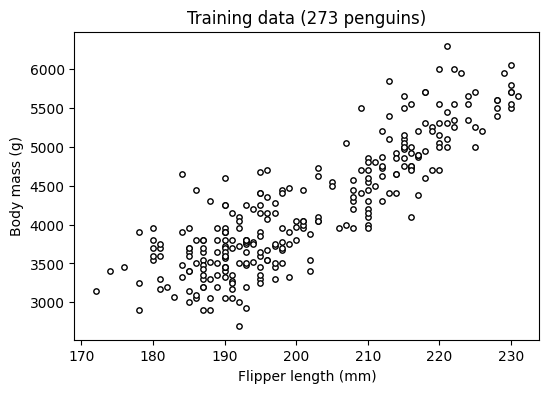

In [15]:
print("number of penguins:", len(x))
print("correlation flipper vs mass:", round(np.corrcoef(x, y)[0, 1], 3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x_tr, y_tr, s=15, facecolor="white", edgecolor="black")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.set_title("Training data (273 penguins)")
plt.show()

**Question B1:** describe the relationship you see in the plot in one or two sentences. Does a straight line look reasonable?

**Your answer (B1):**
The scatter plot shows a strong positive relationship between flipper length and body mass because correlation between them near to 1. Penguins with longer flippers tend to be heavier, so a straight line seems reasonable for modelling this relationship.

### B2. Problem formulation (written task, no code)

**Your task:** complete the table in the answer cell — this is the six-question checklist from the lecture. Writing it down *before* modelling is required in every lab and project in this course.

**Your answer (B2):**

| Question | Your answer |
|---|---|
| 1. Input $\mathcal{X}$ (features, units) |Flipper length in mm |
| 2. Output $\mathcal{Y}$ (number or class?) |Body mass in grams, a continuous numerical value|
| 3. Hypothesis class $\mathcal{H}$ | Simple linear regression: $\hat{y} = w_0 + w_1x$|
| 4. Training loss $\ell$ |MSE |
| 5. Evaluation metric(s) |MAE and RMSE on the test set |
| 6. Data split and comparison | 80% training and 20% testing, using random_state=42. Compare the linear model with mean and median constant baselines|

### B3. Baselines computed by hand

A **constant baseline** ignores the feature and predicts the same number $c$ for every penguin. The lecture showed:
- under squared error, the best constant is the **mean** of the training targets;
- under absolute error, it is the **median**.

**Your task:**
1. Compute `c_mean` and `c_median` from the **training** targets `y_tr` only.
2. The loop then predicts each constant for every **test** penguin and prints MAE and RMSE.

**Hint:** `np.mean`, `np.median`. `np.full(len(y_te), c)` creates an array filled with `c`.

**Expected result:** mean ≈ 4218.4 g, median = 4050 g; mean baseline RMSE ≈ 819.6 g.

In [16]:
rmse = lambda y, y_hat: np.sqrt(mse(y, y_hat))

c_mean = np.mean(y_tr)     # TODO: mean of the TRAINING targets
c_median = np.median(y_tr)   # TODO: median of the TRAINING targets

if c_mean is not None and c_median is not None:
    for name, c in [("mean", c_mean), ("median", c_median)]:
        pred = np.full(len(y_te), c)
        print(f"{name:6s} baseline c = {c:7.1f} | test MAE = {mae(y_te, pred):6.1f} | test RMSE = {rmse(y_te, pred):6.1f}")

mean   baseline c =  4218.4 | test MAE =  693.2 | test RMSE =  819.6
median baseline c =  4050.0 | test MAE =  679.3 | test RMSE =  819.9


In [17]:
# CHECK B3 — do not edit
assert c_mean is not None and np.isclose(c_mean, 4218.4066, atol=0.01), "c_mean must be the mean of y_tr."
assert c_median == 4050, "c_median must be the median of y_tr."
print("✓ B3")

✓ B3


### B4. ERM over constants — numerically

**What this cell must do:** for 2501 candidate constants $c$ between 3000 and 5500 g, compute the **training** MSE and MAE of the constant prediction, plot both curves, and print where each curve is lowest.

**Your task:** complete the two `TODO` lines that build the lists `mse_c` and `mae_c`. The plotting code is given.

**Hint:** use a list comprehension, e.g. `[mse(y_tr, np.full(len(y_tr), c)) for c in cs]`.

**Expected result:** the MSE curve is lowest at c ≈ 4218 (the training mean) and the MAE curve at c = 4050 (the training median).

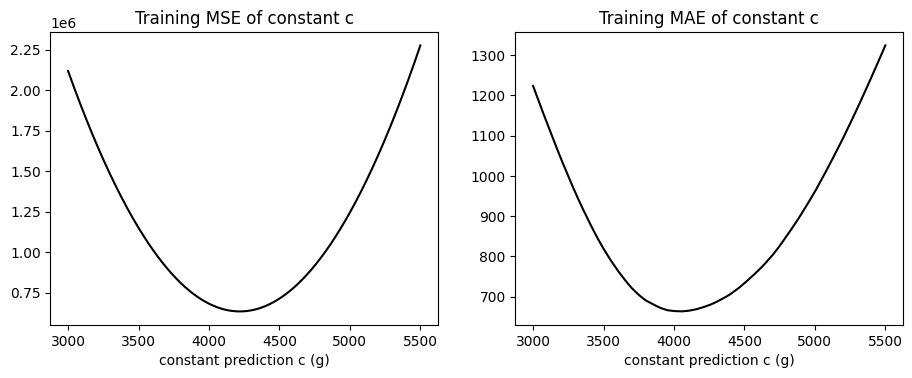

MSE is minimised at c = 4218.0
MAE is minimised at c = 4050.0


In [18]:
cs = np.linspace(3000, 5500, 2501)

mse_c = [mse(y_tr, np.full(len(y_tr), c)) for c in cs]   # TODO: training MSE of predicting c, for every c in cs
mae_c = [mae(y_tr, np.full(len(y_tr), c)) for c in cs]   # TODO: training MAE of predicting c, for every c in cs

if mse_c is not None and mae_c is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    axes[0].plot(cs, mse_c, color="black"); axes[0].set_title("Training MSE of constant c")
    axes[1].plot(cs, mae_c, color="black"); axes[1].set_title("Training MAE of constant c")
    for ax_ in axes:
        ax_.set_xlabel("constant prediction c (g)")
    plt.show()
    print("MSE is minimised at c =", cs[np.argmin(mse_c)])
    print("MAE is minimised at c =", cs[np.argmin(mae_c)])

**Question B4:** where are the two curves minimised? Explain why, using the derivation from the lecture.

**Your answer (B4):**

The MSE curve is minimised at approximately 4218 g, which is the training mean. This happens because setting the derivative of the squared error to zero gives the mean of the target values.The MAE curve is minimised at 4050 g, which is the training median. This is because the median minimises the sum of absolute differences between the predictions and actual values

### B5. The same baseline with scikit-learn

**What this cell does:** fits scikit-learn's `DummyRegressor`, which always predicts the training mean, and prints its first three test predictions. scikit-learn requires the feature as a **2-D** array, hence `.reshape(-1, 1)` (one column, as many rows as needed).

**Your task:** run it and check that the predictions equal your `c_mean`.

**Expected result:** `[4218.4066 4218.4066 4218.4066]`.

In [19]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean").fit(x_tr.reshape(-1, 1), y_tr)
print(dummy.predict(x_te[:3].reshape(-1, 1)))

[4218.4066 4218.4066 4218.4066]


---
# Part C — Linear regression with the normal equations

The least-squares weights satisfy the **normal equations**

$$X^\top X\,\mathbf{w} = X^\top\mathbf{y},$$

where $X$ is the **design matrix**: a column of ones (for the intercept) followed by the feature(s). You will solve them with NumPy and check the answer against two libraries.

### C0. Design matrix and least-squares solution

**What this cell does:** builds the design matrices for the training and test sets with `np.c_[np.ones(n), x]` (the "bias trick" — the intercept becomes the weight of the column of ones).

**Your task:**
1. `w_ne`: solve the normal equations with `np.linalg.solve(X_tr.T @ X_tr, X_tr.T @ y_tr)`.
2. `w_ls`: solve the least-squares problem directly with `np.linalg.lstsq(X_tr, y_tr, rcond=None)` — it returns several things; the weights are the **first** one.

**Expected result:** both give intercept ≈ −5614.07 g and slope ≈ 48.83 g/mm.

In [ ]:
X_tr = np.c_[np.ones(len(x_tr)), x_tr]
X_te = np.c_[np.ones(len(x_te)), x_te]
print("X_tr shape:", X_tr.shape)

w_ne = None   # TODO: solve the normal equations
w_ls = None   # TODO: np.linalg.lstsq(...)[0]

print("normal equations:", w_ne)
print("lstsq           :", w_ls)

### C1. Validate against scikit-learn

**What this cell does:** fits scikit-learn's `LinearRegression` on the raw feature (**without** a column of ones — scikit-learn adds the intercept itself) and checks that its intercept and slope equal your `w_ne` and `w_ls`.

**Your task:** run it. If it fails, look again at C0.

In [ ]:
# CHECK C1 — do not edit
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(x_tr.reshape(-1, 1), y_tr)
print("scikit-learn: intercept", lr.intercept_, "| slope", lr.coef_[0])
assert w_ne is not None and w_ls is not None, "Complete C0 first."
assert np.allclose(w_ne, [lr.intercept_, lr.coef_[0]]) and np.allclose(w_ne, w_ls)
print("✓ C1 — your solution matches NumPy lstsq and scikit-learn")

### C2. Evaluate the model

**What you need to know:**

$$R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}$$

The denominator is exactly the squared error of the **mean baseline**, so $R^2$ says how much of the baseline's error the model removes (1 = perfect, 0 = no better than the mean).

**Your task:** complete the function `r2`. The loop then prints $R^2$, RMSE and MAE on the training and test sets.

**Expected result:** test $R^2 \approx 0.782$, test RMSE ≈ 380.7 g, test MAE ≈ 315.9 g.

In [ ]:
def r2(y, y_hat):
    # TODO: 1 - (sum of squared residuals) / (sum of squared deviations from the mean of y)
    pass

assert w_ne is not None, "Complete C0 first: w_ne is still None."

if r2(y_tr, X_tr @ w_ne) is not None:
    for name, Xm, ym in [("train", X_tr, y_tr), ("test", X_te, y_te)]:
        pred = Xm @ w_ne
        print(f"{name:5s} R2 = {r2(ym, pred):.3f} | RMSE = {rmse(ym, pred):6.1f} | MAE = {mae(ym, pred):6.1f}")

In [ ]:
# CHECK C2 — do not edit
assert w_ne is not None, "Complete C0 first."
assert r2(y_te, X_te @ w_ne) is not None, "Complete r2 first."
assert np.isclose(r2(y_te, X_te @ w_ne), lr.score(x_te.reshape(-1, 1), y_te))
print("✓ C2 — your R² matches scikit-learn's score")

**Question C2:** compare the test RMSE and MAE of the linear model with the baselines from B3. By how much does the model improve on the mean baseline?

**Your answer (C2):**

*Write your answer here — double-click this cell to edit it.*

### C3. The geometry of least squares, numerically

**What this cell does:** computes the training **residuals** $\mathbf{r} = \mathbf{y} - X\mathbf{w}$ and prints their sum and the product $X^\top\mathbf{r}$.

**Your task:** run it and explain the result.

**Expected result:** both are (almost exactly) zero — tiny numbers like `1e-10` are rounding errors.

In [ ]:
assert w_ne is not None, "Complete C0 first: w_ne is still None."
r = y_tr - X_tr @ w_ne
print("sum of residuals:", r.sum())
print("X^T r           :", X_tr.T @ r)

**Question C3:** which equation from the lecture does this verify, and what does it mean geometrically?

**Your answer (C3):**

*Write your answer here — double-click this cell to edit it.*

### C4. Interpret the model

**What this cell does:** prints the slope and the predicted mass for a penguin with a 210 mm flipper.

**Your task:** run it, then interpret the slope in a sentence and answer the question below.

In [ ]:
assert w_ne is not None, "Complete C0 first: w_ne is still None."
print(f"slope: {w_ne[1]:.2f} g per mm")
print(f"predicted mass at 210 mm: {w_ne[0] + w_ne[1] * 210:.0f} g")
print("training flipper range:", x_tr.min(), "to", x_tr.max(), "mm")

**Question C4:** interpret the slope. Why should you **not** use this model for a penguin with a 120 mm flipper?

**Your answer (C4):**

*Write your answer here — double-click this cell to edit it.*

### C5. More features

**What this cell must do:** fit linear regression with **three** features — flipper length, bill length and bill depth — using the normal equations, and report the test $R^2$ and RMSE.

**Your task:** complete the `TODO` lines.
1. Build the design matrices `A_tr`, `A_te` with a column of ones (same trick as C0, but `a_tr` already has 3 columns).
2. Solve the normal equations for `w3`.

**Expected result:** test $R^2 \approx 0.788$, RMSE ≈ 375.6 g.

In [ ]:
p2 = penguins.dropna(subset=["bill_length_mm", "bill_depth_mm"])
features = ["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]
a_tr, a_te, b_tr, b_te = train_test_split(p2[features].to_numpy(), p2["body_mass_g"].to_numpy(),
                                          test_size=0.2, random_state=42)

A_tr = None   # TODO: column of ones + a_tr
A_te = None   # TODO: column of ones + a_te
w3 = None     # TODO: solve the normal equations

if w3 is not None:
    print("weights (intercept, flipper, bill length, bill depth):", w3)
    print(f"test R2 = {r2(b_te, A_te @ w3):.3f} | test RMSE = {rmse(b_te, A_te @ w3):.1f}")

**Question C5:** does the test $R^2$ improve? Is it fair to compare the three coefficients directly to decide which feature is "most important"? Why not?

**Your answer (C5):**

*Write your answer here — double-click this cell to edit it.*

### C6. Residual plot

**What this cell must do:** plot the **test residuals** $y - \hat y$ (vertical axis) against the **test predictions** $\hat y$ (horizontal axis), with a horizontal line at 0.

**Your task:** complete the plot. Label both axes and give it a title.

**Hint:** `plt.scatter(pred_te, y_te - pred_te, ...)`, `plt.axhline(0, color="black")`.

In [ ]:
assert w_ne is not None, "Complete C0 first: w_ne is still None."
pred_te = X_te @ w_ne
# TODO: scatter plot of residuals vs predictions, a horizontal line at 0, labels and a title

**Question C6:** do you see a pattern in the residuals (a curve, a funnel, groups)? What would a pattern tell you?

**Your answer (C6):**

*Write your answer here — double-click this cell to edit it.*

---
# Part D — Gradient descent from scratch

Instead of solving the normal equations in one step, gradient descent starts from $\mathbf{w} = \mathbf{0}$ and repeatedly steps downhill:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta\,\nabla J(\mathbf{w}), \qquad \nabla J(\mathbf{w}) = \frac{2}{n}X^\top(X\mathbf{w}-\mathbf{y})$$

$\eta$ (eta) is the **learning rate**. Because linear regression has an exact answer (`w_ne`), we can check that gradient descent finds it.

### D0. Standardise the feature and write gradient descent

**What this cell does:**
1. Computes the mean `mu` and standard deviation `sd` of flipper length on the **training set only**, and builds standardised design matrices `Xs_tr`, `Xs_te`. (Using training statistics for the test set avoids data leakage.)
2. Defines `gradient_descent(X, y, eta, n_steps)`, which records the loss before every step in `history` so that we can plot a **loss curve**.

**Your task:** complete the one `TODO` line: a gradient step using your `grad_J` from A7.

In [ ]:
mu, sd = x_tr.mean(), x_tr.std()
Xs_tr = np.c_[np.ones(len(x_tr)), (x_tr - mu) / sd]
Xs_te = np.c_[np.ones(len(x_te)), (x_te - mu) / sd]

def gradient_descent(X, y, eta, n_steps):
    w = np.zeros(X.shape[1])
    history = []
    for step in range(n_steps):
        history.append(J(w, X, y))
        w = w   # TODO: replace with one gradient step: w - eta * gradient
    history.append(J(w, X, y))
    return w, np.array(history)

### D1. Run gradient descent and compare with the exact solution

**What this cell does:** runs 200 steps with $\eta = 0.1$, plots the loss curve (log scale), converts the weights from standardised units back to millimetres, and checks them against `w_ne`.

Converting back: if $\hat y = w_0 + w_1\frac{x-\mu}{\sigma}$, then the slope per mm is $w_1/\sigma$ and the intercept is $w_0 - \frac{w_1}{\sigma}\mu$.

**Your task:** run it.

**Expected result:** `w_gd ≈ [4218.41, 690.44]`; after conversion, intercept ≈ −5614.07, slope ≈ 48.83 — identical to `w_ne`.

In [ ]:
w_gd, hist = gradient_descent(Xs_tr, y_tr, eta=0.1, n_steps=200)
slope = w_gd[1] / sd
intercept = w_gd[0] - slope * mu

plt.figure(figsize=(6, 3.8))
plt.semilogy(hist, color="black")
plt.xlabel("step"); plt.ylabel("training MSE (log scale)")
plt.title("Gradient descent, η = 0.1")
plt.show()
print("w_gd (standardised):", w_gd)
print("converted: intercept", round(intercept, 2), "| slope", round(slope, 2))

# CHECK D1 — do not edit
assert w_ne is not None, "Complete C0 first."
assert np.allclose([intercept, slope], w_ne), "Gradient descent did not reach the least-squares solution."
print("✓ D1 — gradient descent matches the normal equations")

**Question D1:** why is the first weight `w_gd[0]` (the intercept in standardised units) exactly equal to the mean of the training targets?

**Your answer (D1):**

*Write your answer here — double-click this cell to edit it.*

### D2. The learning rate

**What this cell must do:** run 100 steps of gradient descent for six learning rates and plot all six loss curves **in one figure** (log y-axis, legend), so you can compare them. Line styles are given so the plot is readable in black and white.

**Your task:** inside the loop, call `gradient_descent(Xs_tr, y_tr, eta, 100)`, plot its history with `plt.semilogy(...)` using the given line style and a label, and print the final loss.

**Expected result (final loss after 100 steps):** η = 0.001 → ≈ 1.24e7 (very slow); 0.01 → ≈ 4.8e5; 0.1, 0.5, 0.9 → ≈ 1.572e5 (converged); 1.05 → explodes (≈ 3.5e15).

In [ ]:
etas = [0.001, 0.01, 0.1, 0.5, 0.9, 1.05]
styles = [":", "--", "-", "-.", (0, (5, 1)), (0, (1, 1))]

plt.figure(figsize=(7, 4.5))
for eta, ls in zip(etas, styles):
    # TODO: run gradient descent for 100 steps with this eta,
    #       plot the history with plt.semilogy(h, color="black", ls=ls, label=f"η = {eta}"),
    #       and print eta and the final loss h[-1]
    pass
plt.ylim(1e5, 1e9)
plt.xlabel("step"); plt.ylabel("training MSE (log scale)")
plt.title("Effect of the learning rate"); plt.legend()
plt.show()

**Question D2:** which learning rates are too small, good, and too large? Explain why η = 0.5 reaches the minimum in a single step.

**Hint:** for a standardised single feature the Hessian of $J$ is $2I$, so the update is $\mathbf{w} \leftarrow \mathbf{w} - \eta\cdot 2(\mathbf{w}-\mathbf{w}^*)$.

**Your answer (D2):**

*Write your answer here — double-click this cell to edit it.*

### D3. What happens without scaling?

**What this cell must do:** run gradient descent on the **unscaled** design matrix `X_tr` (flipper length in raw millimetres, around 200) for three learning rates and 200 steps each.

**Your task:** inside the loop, call `gradient_descent(X_tr, y_tr, eta, 200)` and print `eta`, the final loss and the weights.

**Expected result:** η = 1e-5 and 1e-6 → loss stuck around 3.1e5 with intercept ≈ 0 and slope ≈ 21; η = 2.5e-5 → the loss explodes.

In [ ]:
for eta in [1e-5, 1e-6, 2.5e-5]:
    # TODO: run 200 steps of gradient descent on the UNSCALED X_tr and print eta, final loss and weights
    pass

**Question D3:** explain what goes wrong in each case, using the shape of the loss surface from the lecture.

**Your answer (D3):**

*Write your answer here — double-click this cell to edit it.*

### D4. Mini-batch and stochastic gradient descent

**What this cell does:** defines `minibatch_sgd`. In each **epoch** (one pass through the training data) it shuffles the examples, splits them into mini-batches of size `batch_size`, and takes one gradient step per mini-batch. The training loss is recorded once per epoch.

**Your task:** complete the one `TODO` line: a gradient step computed on the mini-batch only, i.e. on `X[B]` and `y[B]`.

In [ ]:
def minibatch_sgd(X, y, eta, epochs, batch_size, seed=0):
    rng = np.random.default_rng(seed)
    w = np.zeros(X.shape[1])
    n = len(y)
    history = []
    for epoch in range(epochs):
        idx = rng.permutation(n)                  # shuffle every epoch
        for start in range(0, n, batch_size):
            B = idx[start:start + batch_size]     # indices of this mini-batch
            w = w   # TODO: gradient step on X[B], y[B]
        history.append(J(w, X, y))
    return w, np.array(history)

**What this cell does:** compares batch size 1 (stochastic GD), 16 (mini-batch) and 273 (= the whole training set, i.e. batch GD) with η = 0.05 for 20 epochs, and plots the loss per epoch.

**Your task:** run it, then answer below.

**Expected result (loss after 20 epochs):** batch 1 ≈ 178,100; batch 16 ≈ 159,151; batch 273 ≈ 427,263.

In [ ]:
plt.figure(figsize=(7, 4.5))
for bs, ls in [(1, ":"), (16, "-"), (273, "--")]:
    w_b, h_b = minibatch_sgd(Xs_tr, y_tr, eta=0.05, epochs=20, batch_size=bs)
    plt.semilogy(range(1, 21), h_b, color="black", ls=ls, label=f"batch size {bs}")
    print(f"batch size {bs:3d}: loss after 20 epochs = {h_b[-1]:.1f}")
plt.xlabel("epoch"); plt.ylabel("training MSE (log scale)")
plt.title("Mini-batch SGD, η = 0.05"); plt.legend()
plt.show()

**Question D4:** which batch size reaches the lowest loss after 20 epochs? Why does the full batch (273) do worst *per epoch*? What do you notice about the batch-size-1 result?

**Your answer (D4):**

*Write your answer here — double-click this cell to edit it.*

### D5. Test error of the gradient-descent model

**What this cell does:** checks that the gradient-descent model has exactly the same test RMSE as the closed-form model (they are the same line).

**Expected result:** ✓ D5 with RMSE ≈ 380.69 g.

In [ ]:
# CHECK D5 — do not edit
assert w_ne is not None and w_gd is not None, "Complete C0 and D1 first."
print("test RMSE (gradient descent):", rmse(y_te, Xs_te @ w_gd))
print("test RMSE (normal equations):", rmse(y_te, X_te @ w_ne))
assert np.isclose(rmse(y_te, Xs_te @ w_gd), rmse(y_te, X_te @ w_ne))
print("✓ D5")

---
# Part E — Ridge and lasso

We now use scikit-learn's **diabetes** dataset: 442 patients, 10 baseline measurements (age, sex, body-mass index `bmi`, blood pressure `bp`, and six blood-serum measurements `s1`–`s6`), and a target measuring disease progression one year later.

- **Ridge** adds $\lambda\lVert\mathbf{w}\rVert_2^2$ to the squared error: it **shrinks** all coefficients.
- **Lasso** adds $\alpha\lVert\mathbf{w}\rVert_1$: it sets some coefficients **exactly to zero** (feature selection).

Both require **standardised features**, and the penalty must **not** apply to the intercept.

### E0. Load, split and standardise the diabetes data

**What this cell does:**
1. Loads the data and splits it 80/20 with `random_state=42` (353 training and 89 test patients).
2. Fits a `StandardScaler` on the **training** features only and transforms both sets (`S_tr`, `S_te`).
3. **Centres** the training target: `yc = yd_tr - y_bar`. With centred targets and standardised features, the model needs no intercept, so the ridge penalty cannot accidentally penalise it. Predictions are then `S @ w + y_bar`.

**Your task:** run it.

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

data = load_diabetes()
Xd, yd, names = data.data, data.target, data.feature_names
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(Xd_tr)          # fit on training data only
S_tr, S_te = scaler.transform(Xd_tr), scaler.transform(Xd_te)
y_bar = yd_tr.mean()
yc = yd_tr - y_bar                            # centred target

print("train:", S_tr.shape, "| test:", S_te.shape, "| features:", names)

### E1. Ridge regression in closed form

**What you need to know:**

$$\hat{\mathbf{w}}_{\text{ridge}} = (X^\top X + \lambda I)^{-1}X^\top\mathbf{y}$$

**Your task:**
1. Complete `ridge_closed(Xs, yc, lam)` using `np.linalg.solve` (not `inv`). `np.eye(d)` is the $d\times d$ identity matrix.
2. The loop then reports, for λ ∈ {0, 1, 10, 100}, the test MSE and the size (L2 norm) of the coefficients, and also the test MSE of the mean baseline.

**Expected result:** baseline 5361.5; test MSE 2900.2 (λ = 0), 2892.0 (1), 2875.8 (10), 2858.2 (100); the norm shrinks 71.6 → 60.9 → 43.0 → 34.3.

In [ ]:
def ridge_closed(Xs, yc, lam):
    d = Xs.shape[1]
    # TODO: solve (Xs^T Xs + lam * I) w = Xs^T yc and return w
    pass

assert mse(np.zeros(2), np.ones(2)) is not None, "Complete mse in Part A first."
print("mean baseline test MSE:", round(mse(yd_te, np.full(len(yd_te), y_bar)), 1))
if ridge_closed(S_tr, yc, 1.0) is not None:
    for lam in [0, 1, 10, 100]:
        w_r = ridge_closed(S_tr, yc, lam)
        print(f"λ = {lam:3d} | test MSE = {mse(yd_te, S_te @ w_r + y_bar):7.1f} | ‖w‖ = {np.linalg.norm(w_r):5.1f}")

**What this cell does:** checks that your coefficients are identical to scikit-learn's `Ridge(alpha=λ)` for λ = 1, 10, 100.

In [ ]:
# CHECK E1 — do not edit
assert ridge_closed(S_tr, yc, 1.0) is not None, "Complete ridge_closed first."
for lam in [1, 10, 100]:
    assert np.allclose(ridge_closed(S_tr, yc, lam), Ridge(alpha=lam).fit(S_tr, yd_tr).coef_)
print("✓ E1 — your ridge matches scikit-learn")

**Question E1:** what happens to the size of the coefficients as λ grows? Does the test error improve compared with λ = 0 (ordinary least squares)?

**Your answer (E1):**

*Write your answer here — double-click this cell to edit it.*

### E2. Lasso and sparsity

**What this cell must do:** for several values of α, fit `Lasso(alpha=α, max_iter=100000)` on the standardised training data and report the test MSE, the **number of non-zero coefficients** and the **names** of the features that are kept.

**Your task:** complete the loop body.

**Hint:** `np.flatnonzero(model.coef_)` returns the indices of non-zero coefficients; `names[i]` gives the feature name.

**Expected result:** α = 0.5 keeps 9 features, α = 2 keeps 7, α = 5 keeps 5 (sex, bmi, bp, s3, s5).

In [ ]:
for alpha in [0.01, 0.1, 0.5, 1, 2, 5]:
    # TODO: fit Lasso, compute the test MSE, find the kept features, and print all three
    pass

> **Why are these α values different from the lecture?** In the lecture we used the diabetes features as scikit-learn provides them (already rescaled to small values). Here you standardised them yourself, so each feature has standard deviation 1. The penalty strength that produces a given amount of shrinkage **depends on the scale of the features** — one more reason to always standardise before regularising and to *tune* α rather than copy a value.

**Question E2:** how does the number of features change with α? Which features survive the largest penalty?

**Your answer (E2):**

*Write your answer here — double-click this cell to edit it.*

### E3. Coefficient paths

**What this cell must do:** for 50 values of α between 0.01 and 100 (log scale), fit ridge and lasso and store the coefficients, then plot the two **coefficient paths** side by side. `bmi` and `s5` are drawn in black; the other features in grey, so the plot works in black and white.

**Your task:** complete the two `TODO` lines that build the arrays `coef_ridge` and `coef_lasso` (shape 50 × 10). For ridge use `alpha * 100` so that both plots cover a comparable range of shrinkage.

**Hint:** a list comprehension such as `np.array([Ridge(alpha=a * 100).fit(S_tr, yd_tr).coef_ for a in alphas])`.

In [ ]:
alphas = np.logspace(-2, 2, 50)

coef_ridge = None   # TODO: 50 x 10 array of ridge coefficients (use alpha * 100)
coef_lasso = None   # TODO: 50 x 10 array of lasso coefficients (max_iter=100000)

if coef_ridge is not None and coef_lasso is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
    for j, name in enumerate(names):
        bold = name in ("bmi", "s5")
        for ax_, coefs in zip(axes, [coef_ridge, coef_lasso]):
            ax_.plot(alphas, coefs[:, j], color="black" if bold else "grey",
                     lw=2.2 if bold else 1, label=name if bold else None)
    for ax_, title in zip(axes, ["Ridge: smooth shrinkage", "Lasso: coefficients hit zero"]):
        ax_.set_xscale("log"); ax_.axhline(0, color="black", lw=0.6)
        ax_.set_xlabel("α (stronger penalty →)"); ax_.set_ylabel("coefficient")
        ax_.set_title(title); ax_.legend()
    plt.show()

**Question E3:** describe the difference between the two paths. Which features survive longest in the lasso path?

**Your answer (E3):**

*Write your answer here — double-click this cell to edit it.*

### E4. Choosing the penalty honestly

The penalty is a **hyperparameter**: it must be chosen on data that is **not** the test set.

**What this cell must do:**
1. Split the **training** set again: 75 % for fitting (`Xa`, `ya`), 25 % for validation (`Xv`, `yv`), `random_state=0`.
2. Fit a **new** scaler on the fitting part only.
3. For each candidate α, fit the model on the fitting part and compute the MSE on the validation part.
4. Choose the α with the lowest validation MSE, refit on the **full** training set (`S_tr`, `yd_tr`) and report the test MSE **once**.

**Your task:** the ridge version is set up for you — complete the `TODO` lines. Then do the same for lasso with α ∈ {0.01, 0.03, 0.1, 0.3, 1, 3}.

**Hint:** a dictionary comprehension `{a: validation_mse for a in candidates}` and `min(val, key=val.get)` give the best α.

In [ ]:
Xa, Xv, ya, yv = train_test_split(Xd_tr, yd_tr, test_size=0.25, random_state=0)
sc2 = StandardScaler().fit(Xa)          # scaler fitted on the fitting part only
Xa_s, Xv_s = sc2.transform(Xa), sc2.transform(Xv)

# --- ridge ---
ridge_candidates = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
val_ridge = None    # TODO: {alpha: validation MSE of Ridge(alpha) fitted on (Xa_s, ya)}
best_ridge = None   # TODO: alpha with the lowest validation MSE

# --- lasso ---
lasso_candidates = [0.01, 0.03, 0.1, 0.3, 1, 3]
# TODO: same procedure for Lasso (max_iter=100000)

# TODO: refit the chosen models on (S_tr, yd_tr) and print their TEST MSE once

**Question E4:** which α values were chosen, and does regularisation help on this split? Why must the test set never be used to choose α?

**Your answer (E4):**

*Write your answer here — double-click this cell to edit it.*

---
# Part F — Reflection

Answer each question in a few sentences in the answer cells. Use numbers from your own results where possible.

**Question F1:** explain in your own words why the training MSE of the least-squares model is an optimistic estimate of its true risk.

**Your answer (F1):**

*Write your answer here — double-click this cell to edit it.*

**Question F2:** give two situations where you would prefer gradient descent to the normal equations, and one where you would not.

**Your answer (F2):**

*Write your answer here — double-click this cell to edit it.*

**Question F3:** your gradient-descent loss becomes `nan` after a few steps. List three possible causes and how you would check each.

**Your answer (F3):**

*Write your answer here — double-click this cell to edit it.*

**Question F4:** on the diabetes data, would you report ridge, lasso or plain least squares? Justify with your numbers and mention one limitation of your evaluation.

**Your answer (F4):**

*Write your answer here — double-click this cell to edit it.*

---
## Submission checklist

Tick each item (replace `[ ]` with `[x]`) before you submit:

- [ ] I filled in my name, group and date at the top.
- [ ] Every `TODO` is completed.
- [ ] Every `CHECK` cell prints ✓ (A2, A5, A6, A7, B3, C1, C2, D1, D5, E1).
- [ ] Every "Your answer" cell contains my own explanation.
- [ ] All plots have a title, labelled axes and a legend where needed, and are readable in black and white.
- [ ] **Runtime → Restart and run all** runs to the end without errors.
- [ ] The file is named `Lab02_<Surname>_<Name>.ipynb` and submitted before the deadline.